# Лабораторная 3: GRU encoder-decoder для задачи seq2seq

**Навигация:** Блок `01-RNN` · `ЛР03` · Шаг 3 курса

## Цель
Реализовать модель `seq2seq` на базе `GRU`, которая разворачивает входную последовательность в обратном порядке.

Формат `seq2seq` означает: длина входа и длина выхода могут различаться, а генерация выхода идет пошагово.


## Что нужно знать до старта

Вы сейчас здесь: `01-RNN / ЛР03` — локальная ЛР03 блока `RNN`, Шаг 3 курса.
Предыдущий шаг: `01-RNN / ЛР02`.
Следующий шаг: `02-Attention / ЛР01`.

Перед стартом откройте:
- [Foundations entry-point](../../00-Foundations/README.md)
- [Shared-guide по токенам и decoder shift](../../00-Foundations/guides/02_tokens_padding_and_decoder_shift.md)
- [База по обозначениям и формам](guides/00_prerequisites_and_notation.md)
- [Beginner guide по токенам и seq2seq](guides/03_gru_seq2seq_tokens_beginner.md)
- [walkthrough для этой ЛР](guides/03_gru_seq2seq_walkthrough.md)
- [shared debugging playbook](../../00-Foundations/guides/04_self_study_debugging_playbook.md)

Что важно помнить:
- здесь мы уже работаем не с вещественными признаками, а с дискретными токенами из словаря;
- специальные токены `PAD`, `SOS`, `EOS` управляют выравниванием, стартом декодера и завершением вывода;
- `decoder_input` и `decoder_target` сдвинуты на один шаг относительно друг друга;
- во время обучения используется `teacher forcing`, поэтому декодер видит правильный предыдущий токен.

## Выбор runtime

Здесь вы выбираете, где и на чём запускать notebook.

Что обычно выбирать:
- `auto` — лучший вариант по умолчанию. Если TensorFlow видит GPU, будет выбран GPU. Если GPU нет, notebook спокойно останется на CPU.
- `local-cpu` — локальный запуск только на CPU, даже если видеокарта есть.
- `local-gpu` — локальный запуск с обязательным GPU. Если GPU не настроен, notebook специально остановится с понятной ошибкой.
- `colab-cpu` / `colab-gpu` — запуск в Google Colab.
- `kaggle-cpu` / `kaggle-gpu` — запуск в Kaggle Notebooks.

Что важно:
- после изменения `RUNTIME_MODE` используйте `Restart & Run All`;
- `COURSE_REPO_HTTPS_URL` нужен только для Colab/Kaggle, если репозиторий ещё не клонирован в runtime;
- пока в ячейке стоит placeholder-URL, cloud auto-bootstrap не сможет сам скачать курс;
- guide `05` отвечает на вопрос, где и как запускать notebook;
- guide `06` нужен, если вы хотите именно локальный GPU и не уверены в версиях `TensorFlow` / `CUDA`;
- локальный GPU-path курса: `Linux + NVIDIA` или `Windows -> WSL2 + Ubuntu`;
- если `local-gpu` упирается в локальные CUDA/PTX ошибки, это обычно уже проблема GPU-стека, а не notebook. В таком случае спокойно переключайтесь на `local-cpu`, `colab-gpu` или `kaggle-gpu`.

Подробные guides:
- `themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md`
- `themes/00-Foundations/guides/06_tensorflow_cuda_version_selection.md`


In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/01-RNN/lab/requirements.txt"


def _detect_notebook_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


#_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)
#
#from course_runtime import setup_notebook_runtime
#
#runtime_info = setup_notebook_runtime(
#    runtime_mode=RUNTIME_MODE,
#    course_repo_https_url=COURSE_REPO_HTTPS_URL,
#    notebook_requirements=NOTEBOOK_REQUIREMENTS,
#)
#runtime_info.as_dict()


## Интуиция задачи без формул

Энкодер сначала читает входную последовательность и сжимает её смысл в скрытое состояние. Затем декодер, опираясь на это состояние, начинает выдавать ответ по одному токену за шаг. В нашей toy-задаче ответом является та же последовательность, но в обратном порядке.

Главное новое отличие от прошлых лабораторных: вход и выход здесь разделены. Мы не просто ставим метку входу, а генерируем целую новую последовательность. Поэтому появляется декодер, сдвиг `decoder_input`/`decoder_target` и специальный токен начала `SOS`.


## Как проходить эту ЛР без преподавателя

Рекомендуемый self-study маршрут:
1. Прочитайте [пререквизиты](guides/00_prerequisites_and_notation.md), [beginner guide](guides/03_gru_seq2seq_tokens_beginner.md), [walkthrough](guides/03_gru_seq2seq_walkthrough.md) и [debugging playbook](guides/00_self_study_debugging_playbook.md).
2. Идите по notebook строго сверху вниз и после каждого `TODO` запускайте ближайшую мини-проверку.
3. Если застряли на одном шаге, открывайте walkthrough только для текущего блока, а не для всей лабораторной сразу.
4. [Solution notebook](solutions/03_gru_seq2seq_reverse_toy_solution.ipynb) открывайте только после собственной попытки и ручной проверки сдвига decoder.
5. Если notebook подозрительно запутался в старом состоянии, используйте `Restart & Run All`.


## Что изменилось после `01-RNN / ЛР02`

В `01-RNN / ЛР02` модель ставила метку на каждом шаге той же последовательности.

Теперь меняется сам формат задачи:
- encoder читает одну последовательность;
- decoder генерирует другую;
- появляются два входа модели и отдельный целевой тензор decoder;
- вместо локальной метки на шаге теперь нужен выбор токена из словаря.

Главный практический вывод: здесь важно не только собрать модель, но и идеально понять сдвиг `decoder_input` / `decoder_target`.


## Контракт данных
Используются целочисленные токены:
- `1..9` — содержательные значения;
- `PAD=0` — заполнение;
- `SOS=10` — старт декодера;
- `EOS=11` — конец последовательности.

Формируются три связанных тензора:
- `encoder_input`;
- `decoder_input`;
- `decoder_target`.


## Таблица форм тензоров

| Тензор | Форма | Смысл | Где используется |
|---|---|---|---|
| `encoder_input` | `(N, T_in)` | Вход кодировщика | `model.fit`/`model.predict` |
| `decoder_input` | `(N, T_out)` | Вход декодера со сдвигом | `model.fit`/`model.predict` |
| `decoder_target` | `(N, T_out, 1)` | Истинные выходные токены | Функция потерь |
| `probs` | `(N_test, T_out, V)` | Распределения вероятностей по словарю | `model.predict` |
| `preds` | `(N_test, T_out)` | Предсказанные индексы токенов | Оценка |
| `mask` | `(N_test, T_out)` | Маска значимых токенов (`!= PAD`) | `exact_match` |
| `exact_match` | скаляр | Доля полностью верных последовательностей | Итоговая метрика |


## Шпаргалка по обозначениям и формам

Короткая карта обозначений:
- `V` - размер словаря вместе со специальными токенами.
- `encoder_input`: входная последовательность токенов для энкодера.
- `decoder_input`: последовательность для входа декодера, начинающаяся с `SOS`.
- `decoder_target`: правильная целевая последовательность для обучения декодера.
- `PAD`, `SOS`, `EOS` - специальные токены паддинга, старта и конца.
- `mask` - маска, которая помогает игнорировать `PAD`.

Формы тензоров:
- `encoder_input`: `(N, T_in)`.
- `decoder_input`: `(N, T_out)`.
- `decoder_target`: `(N, T_out, 1)`.
- выход модели: `(batch, T_out, V)`.
- `token_accuracy` смотрит на отдельные позиции, а `exact_match` требует полностью правильную последовательность.


## Контракт модели
- В `model.fit` передается список входов `[encoder_input, decoder_input]` и `decoder_target`.
- Выход модели: распределение вероятностей по словарю на каждом шаге декодера.
- Для функции потерь `sparse_categorical_crossentropy` целевые значения задаются целыми индексами классов.


## Мини-теория
`seq2seq` с кодировщиком и декодером в нотации теории:

$$
h_t^{enc} = f_{enc}(x_t, h_{t-1}^{enc}), \quad c_{enc}=h_{T_{in}}^{enc}
$$

$$
h_t^{dec} = f_{dec}(E(y_{t-1}^{in}), h_{t-1}^{dec}, c_{enc}), \quad
s_t^{dec} = W_{out}h_t^{dec} + b_{out}, \quad
\hat{y}_t = \mathrm{softmax}(s_t^{dec})
$$

На обучении используется обучение с учителем по предыдущему токену (`teacher forcing`).


## Ручной разбор одного примера

Пусть вход для энкодера равен `[2, 5, 7]`, а задача - выдать его в обратном порядке.

Тогда:
- правильный ответ без служебных токенов: `[7, 5, 2]`
- `decoder_input`: `[SOS, 7, 5, 2]`
- `decoder_target`: `[7, 5, 2, EOS]`

Смысл сдвига такой: на каждом шаге декодер получает предыдущий правильный токен и учится предсказать следующий. Именно поэтому `decoder_input` и `decoder_target` почти одинаковы, но сдвинуты на одну позицию.


In [2]:
PAD, SOS, EOS = 0, 10, 11
seq = [2, 5, 7]
reversed_seq = list(reversed(seq))
decoder_input = [SOS] + reversed_seq
decoder_target = reversed_seq + [EOS]

print('encoder_input :', seq)
print('target tokens :', reversed_seq)
print('decoder_input :', decoder_input)
print('decoder_target:', decoder_target)


encoder_input : [2, 5, 7]
target tokens : [7, 5, 2]
decoder_input : [10, 7, 5, 2]
decoder_target: [7, 5, 2, 11]


In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(42)
print('Версия TensorFlow:', tf.__version__)

Версия TensorFlow: 2.21.0


## Генерация данных
**Что сделать:** подготовить `encoder_input`, `decoder_input`, `decoder_target` со сдвигом на один шаг.

**Почему:** декодер обучается предсказывать следующий токен по предыдущему.

**Ожидаемые формы:** `(N,T_in)`, `(N,T_out)`, `(N,T_out,1)`.

**Частая ошибка:** неверный сдвиг между входом и целями декодера.


### Подсказка к TODO 1-3: данные

Концептуальная подсказка:
- здесь нужно не просто развернуть последовательность, а подготовить три связанные версии одного примера: `encoder_input`, `decoder_input`, `decoder_target`.

Implementation hint:
- `rev = seq[::-1]`;
- `decoder_input` начинается с `SOS`;
- `decoder_target` заканчивается на `EOS`;
- итоговая форма `decoder_target` должна быть `(N, T_out, 1)`.

Если застряли, откройте раздел про TODO 1-3 в [walkthrough](guides/03_gru_seq2seq_walkthrough.md).


In [4]:
PAD_ID = 0
SOS_ID = 10
EOS_ID = 11
VOCAB_SIZE = 12
ENC_LEN = 6
DEC_LEN = ENC_LEN + 1


def make_one_sample(min_len: int = 3, max_len: int = ENC_LEN):
    length = np.random.randint(min_len, max_len + 1)
    seq = np.random.randint(1, 10, size=length, dtype=np.int32)
    # TODO 1: получите обратную последовательность
    rev = seq[::-1]
    return seq, rev


def pad_sequence(seq, target_len, pad_value=PAD_ID):
    out = np.full((target_len,), pad_value, dtype=np.int32)
    out[:len(seq)] = seq
    return out


def make_dataset(n_samples: int = 7000):
    encoder_input = np.zeros((n_samples, ENC_LEN), dtype=np.int32)
    decoder_input = np.zeros((n_samples, DEC_LEN), dtype=np.int32)
    decoder_target = np.zeros((n_samples, DEC_LEN), dtype=np.int32)

    for i in range(n_samples):
        seq, rev = make_one_sample()
        enc = pad_sequence(seq, ENC_LEN)

        # TODO 2: сформируйте вход декодера: [SOS] + rev
        dec_in = np.array([SOS_ID] + rev.tolist())
        # TODO 3: сформируйте целевой выход декодера: rev + [EOS]
        dec_out = np.array(rev.tolist() + [EOS_ID])

        encoder_input[i] = pad_sequence(enc, ENC_LEN)
        decoder_input[i] = pad_sequence(dec_in, DEC_LEN)
        decoder_target[i] = pad_sequence(dec_out, DEC_LEN)

    return encoder_input, decoder_input, decoder_target[..., None]


enc_in, dec_in, dec_tgt = make_dataset()

enc_train, enc_test, dec_in_train, dec_in_test, dec_tgt_train, dec_tgt_test = train_test_split(
    enc_in,
    dec_in,
    dec_tgt,
    test_size=0.2,
    random_state=42,
)

print('Форма enc_train   :', enc_train.shape)
print('Форма dec_in_train:', dec_in_train.shape)
print('Форма dec_tgt_train:', dec_tgt_train.shape)

Форма enc_train   : (5600, 6)
Форма dec_in_train: (5600, 7)
Форма dec_tgt_train: (5600, 7, 1)


### Разбор TODO 1-3: данные

После заполнения блока проверьте логику, а не только синтаксис:
- `rev` действительно разворачивает порядок токенов;
- `decoder_input` и `decoder_target` сдвинуты на один шаг;
- `PAD` используется только для выравнивания длины, а не как содержательный токен.


In [5]:
# Мини-проверка данных
assert enc_in.ndim == 2 and dec_in.ndim == 2, 'encoder_input и decoder_input должны быть двумерными'
assert dec_tgt.ndim == 3 and dec_tgt.shape[-1] == 1, 'decoder_target должен иметь форму (N,T,1)'
assert enc_in.shape[1] == ENC_LEN and dec_in.shape[1] == DEC_LEN
print('Мини-проверка данных: OK')

Мини-проверка данных: OK


### Что должно получиться после шага "Данные"

Ожидаемые сигналы:
- `enc_train.shape == (N_train, ENC_LEN)`;
- `dec_in_train.shape == (N_train, DEC_LEN)`;
- `dec_tgt_train.shape == (N_train, DEC_LEN, 1)`;
- мини-проверка данных проходит без ошибок.

Self-check checkpoint:
- выберите один пример;
- вручную выпишите `rev`, `decoder_input` и `decoder_target`;
- убедитесь, что `decoder_input[0] == SOS`, а последний значимый токен `decoder_target` равен `EOS`.


## Модель
Используется гибридная схема:
- кодировщик и встраивание декодера собираются через `Sequential.add(...)`;
- объединение двух входов выполняется через функциональный граф (`Functional API`).

Такой вариант сохраняет прозрачную структуру и поддерживает два входа `seq2seq`.


### Подсказка к TODO 4-9: модель

Концептуальная подсказка:
- encoder должен сжать вход в контекст, а decoder — развернуть этот контекст обратно в последовательность токенов.

Implementation hint:
- в encoder нужен `Embedding(..., mask_zero=True)` и `GRU`;
- в decoder нужен свой `Embedding(..., mask_zero=True)` и `GRU(return_sequences=True)`;
- финальный слой должен выдавать распределение по словарю `VOCAB_SIZE`;
- компиляция идёт через `sparse_categorical_crossentropy`, потому что таргет хранит индексы токенов.

Если форма выхода не сходится, откройте [walkthrough](guides/03_gru_seq2seq_walkthrough.md).


In [6]:
def build_model(vocab_size: int = VOCAB_SIZE, emb_dim: int = 24, latent_dim: int = 48):
    encoder_inputs = tf.keras.layers.Input(shape=(ENC_LEN,), name='encoder_inputs')

    encoder_seq = tf.keras.Sequential(name='encoder_seq')
    # TODO 4: добавьте слой Embedding в encoder_seq
    encoder_seq.add(tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True))
    # TODO 5: добавьте слой GRU в encoder_seq для получения контекста
    encoder_seq.add(tf.keras.layers.GRU(latent_dim))
    context = encoder_seq(encoder_inputs)

    decoder_inputs = tf.keras.layers.Input(shape=(DEC_LEN,), name='decoder_inputs')
    decoder_seq = tf.keras.Sequential(name='decoder_seq')
    # TODO 6: добавьте слой Embedding в decoder_seq
    decoder_seq.add(tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True))
    dec_emb = decoder_seq(decoder_inputs)

    # TODO 7: создайте GRU декодера (return_sequences=True, initial_state=context)
    dec_gru = tf.keras.layers.GRU(latent_dim, return_sequences=True, name='dec_gru')
    dec_out = dec_gru(dec_emb, initial_state=context)

    head_seq = tf.keras.Sequential(name='output_head')
    # TODO 8: добавьте Dense(VOCAB_SIZE, activation='softmax')
    head_seq.add(tf.keras.layers.Dense(vocab_size, activation='softmax'))
    outputs = head_seq(dec_out)

    model = tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='gru_seq2seq')
    # TODO 9: скомпилируйте модель (adam, sparse_categorical_crossentropy, accuracy)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model


model = build_model()
model.summary()

Model: "gru_seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ decoder_inputs      │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_inputs      │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_seq         │ (None, 7, 24)     │        288 │ decoder_inputs[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_seq         │ (None, 48)        │     10,944 │ encoder_inputs[0… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_gru (GRU)       │ (None, 7, 48)     │     10,656 │ decoder_seq[0][0… │
│                     │                   │            │ encoder_seq[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_head         │ (None, 7, 12)     │        588 │ dec_gru[0][0]     │
│ (Sequential)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 22,476 (87.80 KB)

 Trainable params: 22,476 (87.80 KB)

 Non-trainable params: 0 (0.00 B)

### Разбор TODO 4-9: модель

После заполнения блока проверьте четыре идеи:
- encoder действительно отдаёт контекст для decoder;
- decoder возвращает последовательность скрытых состояний, а не один вектор;
- `Dense(VOCAB_SIZE, activation='softmax')` строит распределение по словарю на каждом шаге;
- `model.output_shape` должен стать `(None, DEC_LEN, VOCAB_SIZE)`.


In [7]:
# Мини-проверка модели
assert model.output_shape[1] == DEC_LEN, 'Длина выхода должна совпадать с DEC_LEN'
assert model.output_shape[2] == VOCAB_SIZE, 'Последняя ось должна быть равна размеру словаря'
print('Мини-проверка модели: OK')

Мини-проверка модели: OK


### Что должно получиться после шага "Модель"

Ожидаемые сигналы:
- `model.summary()` показывает два входа и выход формы `(None, DEC_LEN, VOCAB_SIZE)`;
- мини-проверка модели проходит;
- вы можете словами объяснить, почему последняя ось выхода равна размеру словаря, а не `1`.

Self-check checkpoint:
- представьте один батч из 64 объектов;
- объясните, почему модель должна вернуть `64 × DEC_LEN` распределений по `VOCAB_SIZE` токенам.


## Трассировка одного примера через модель
Проверка форм тензоров:
1. входы кодировщика и декодера;
2. выход рекуррентного слоя декодера;
3. итоговое распределение вероятностей по словарю.


In [8]:
sample_enc = enc_train[:1]
sample_dec = dec_in_train[:1]

trace_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=[model.get_layer('dec_gru').output, model.output],
)

dec_gru_out, probs_out = trace_model.predict([sample_enc, sample_dec], verbose=0)

print('Вход encoder_input :', sample_enc.shape)
print('Вход decoder_input :', sample_dec.shape)
print('После GRU декодера :', dec_gru_out.shape)
print('После выходного слоя:', probs_out.shape)
print('Первые 3 предсказанных индекса:', probs_out.argmax(axis=-1)[0, :3])

Вход encoder_input : (1, 6)
Вход decoder_input : (1, 7)
После GRU декодера : (1, 7, 48)
После выходного слоя: (1, 7, 12)
Первые 3 предсказанных индекса: [10  6  3]


c:\Users\stepa\Documents\УЧЁБА\Власов\БазМатДляИИ\RNN\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'output_head' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


## Как идет обучение внутри эпохи
По каждому мини-батчу выполняется цикл:
1. прямой проход (`forward pass`) для `encoder` и `decoder`;
2. расчет функции потерь по всем шагам декодера;
3. обратное распространение через время (`BPTT`) через оба рекуррентных блока;
4. обновление параметров.

Для `GRU` управление памятью задается воротами обновления и сброса, что обычно дает компромисс между устойчивостью обучения и скоростью по сравнению с более тяжелой `LSTM`.


## Обучение
В `fit` подается пара входов `[encoder_input, decoder_input]` и целевой тензор `decoder_target`.

Для контроля обобщения используется `validation_split=0.2` на обучающей части.


### Подсказка к TODO 10: обучение

Концептуальная подсказка:
- логика `fit` похожа на прошлые лабораторные, но теперь модель получает два входа сразу.

Implementation hint:
- передавайте в `fit` пару `[enc_train, dec_in_train]`;
- целевой тензор — `dec_tgt_train`;
- используйте `validation_split=0.2`, `batch_size=64` и аргумент `epochs`.

Если история обучения не создаётся, откройте [debugging playbook](guides/00_self_study_debugging_playbook.md).


In [9]:
def train_model(model, enc_train, dec_in_train, dec_tgt_train, epochs: int = 16):
    # TODO 10: обучите модель с validation_split=0.2 и batch_size=64
    history = model.fit([enc_train, dec_in_train], dec_tgt_train, validation_split=0.2, batch_size=64, epochs=epochs)
    return history


history = train_model(model, enc_train, dec_in_train, dec_tgt_train)

Epoch 1/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2698 - loss: 2.1708 - val_accuracy: 0.4069 - val_loss: 1.8151
Epoch 2/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4287 - loss: 1.6501 - val_accuracy: 0.4550 - val_loss: 1.5110
Epoch 3/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4887 - loss: 1.3905 - val_accuracy: 0.5241 - val_loss: 1.2919
Epoch 4/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5707 - loss: 1.1833 - val_accuracy: 0.6309 - val_loss: 1.0655
Epoch 5/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6881 - loss: 0.9358 - val_accuracy: 0.7419 - val_loss: 0.8082
Epoch 6/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7854 - loss: 0.6963 - val_accuracy: 0.8311 - val_loss: 0.5934
Epoch 7/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8573 - loss: 0.5090 - val_accuracy: 0.8834 - val_loss: 0.4366
Epoch 8/16
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9040 - loss: 0.3775 - val_accuracy: 0.9179 - val_loss

### Разбор TODO 10: обучение

После заполнения блока проверьте, что вы понимаете каждый аргумент `fit`:
- какие данные идут в encoder и decoder;
- почему `validation_split` берётся только от train;
- почему на этом шаге вы ещё не видите `exact_match` в истории Keras.


In [10]:
# Мини-проверка обучения
assert 'val_loss' in history.history and 'val_accuracy' in history.history
print('Последняя val_accuracy:', float(history.history['val_accuracy'][-1]))
print('Мини-проверка обучения: OK')

Последняя val_accuracy: 0.9831617474555969
Мини-проверка обучения: OK


### Что должно получиться после шага "Обучение"

Ожидаемые сигналы:
- в `history.history` есть `loss`, `val_loss`, `accuracy`, `val_accuracy`;
- `token_accuracy` заметно растёт выше случайного уровня;
- кривая `loss` имеет понятный нисходящий тренд.

Self-check checkpoint:
- можете ли вы объяснить, почему хорошая `val_accuracy` ещё не гарантирует высокий `exact_match`?


## Оценка и диагностика
Считаются:
- `token_accuracy` — доля корректных токенов;
- `exact_match` — доля последовательностей, полностью совпавших по значимым токенам.

`exact_match` вычисляется с маской `target != PAD`.


### Подсказка к TODO 11: метрики

Концептуальная подсказка:
- `token_accuracy` смотрит на отдельные позиции, а `exact_match` требует безошибочной последовательности целиком.

Implementation hint:
- сначала получите `preds = probs.argmax(axis=-1)`;
- затем сравните `preds` и `target` только по значимым позициям;
- PAD-позиции нужно выключить маской `target != PAD_ID`.

Если застряли, откройте раздел про `exact_match` в [walkthrough](guides/03_gru_seq2seq_walkthrough.md).


In [11]:
def evaluate_model(model, enc_test, dec_in_test, dec_tgt_test):
    loss, token_acc = model.evaluate([enc_test, dec_in_test], dec_tgt_test, verbose=0)
    probs = model.predict([enc_test, dec_in_test], verbose=0)
    preds = probs.argmax(axis=-1)
    target = dec_tgt_test[:, :, 0]
    mask = (target != PAD_ID)

    # TODO 11: вычислите exact_match по значимым токенам
    exact_match = ( (preds == target) | ~mask ).all(axis=1).mean()

    return {
        'loss': float(loss),
        'token_accuracy': float(token_acc),
        'exact_match': float(exact_match),
        'preds': preds,
        'target': target,
        'mask': mask,
        'probs': probs,
    }


metrics = evaluate_model(model, enc_test, dec_in_test, dec_tgt_test)
print({k: v for k, v in metrics.items() if k in ('loss', 'token_accuracy', 'exact_match')})

{'loss': 0.09388883411884308, 'token_accuracy': 0.9804148077964783, 'exact_match': 0.9057142857142857}


### Разбор TODO 11: метрики

После заполнения блока проверьте логику строгой оценки:
- `preds` и `target` должны иметь одинаковую форму `(N, T_out)`;
- маска должна игнорировать только PAD-позиции;
- `exact_match` усредняется по объектам, а не по токенам.


In [12]:
# Мини-проверка метрик
assert 0.0 <= metrics['token_accuracy'] <= 1.0
assert 0.0 <= metrics['exact_match'] <= 1.0
if metrics['exact_match'] >= 0.80:
    print('Целевой порог достигнут: exact_match >= 0.80')
else:
    print('Целевой порог не достигнут: проверьте сдвиг decoder_input/decoder_target и параметры обучения')

Целевой порог достигнут: exact_match >= 0.80


### Что должно получиться после шага "Метрики"

Ожидаемые сигналы:
- словарь метрик содержит `loss`, `token_accuracy`, `exact_match`;
- `token_accuracy` обычно выше `exact_match`;
- мини-проверка метрик проходит без ошибок.

Self-check checkpoint:
- возьмите один тестовый пример;
- сравните `preds` и `target` по шагам;
- найдите первую позицию, где локальная ошибка ломает полное совпадение последовательности.


## Как читать графики и метрики

В seq2seq важны две перспективы:
- `token_accuracy` отвечает на вопрос, насколько часто модель угадывает отдельный следующий токен;
- `exact_match` отвечает на вопрос, совпала ли вся последовательность целиком.

Поэтому `token_accuracy` почти всегда растёт быстрее и выглядит оптимистичнее. Но для реального качества генерации более строгий индикатор - именно `exact_match`.

Если `token_accuracy` уже неплохая, а `exact_match` почти не растёт, обычно проблема в накоплении небольших локальных ошибок: каждая позиция по отдельности часто верна, но полностью правильная последовательность всё ещё редка.


## Что ожидать на практике
- В начале обучения `token_accuracy` может расти быстрее `exact_match`.
- Малейшая ошибка в середине последовательности резко снижает `exact_match`.
- Если обе метрики не растут, сначала проверить корректность сдвига `decoder_input` и `decoder_target`.
- Для корректной реализации обычно достигается `exact_match >= 0.80`.


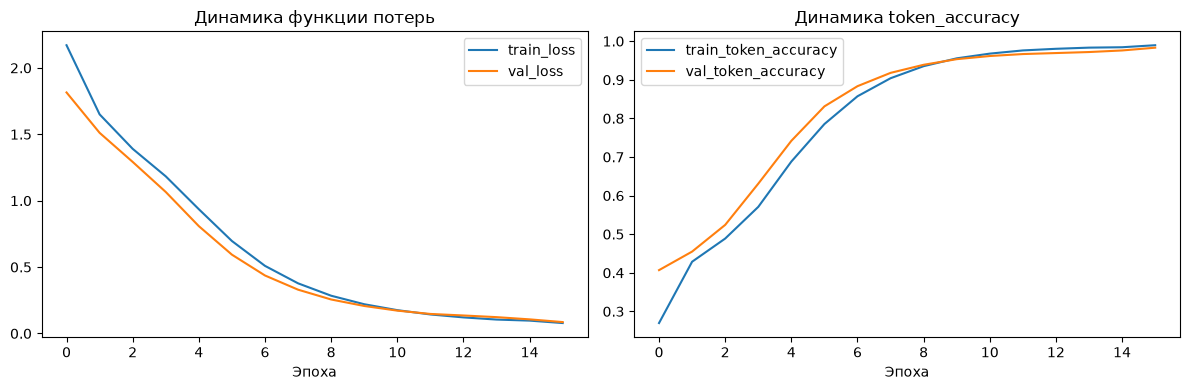

In [13]:
# Визуализация динамики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_token_accuracy')
plt.plot(history.history['val_accuracy'], label='val_token_accuracy')
plt.title('Динамика token_accuracy')
plt.xlabel('Эпоха')
plt.legend()

plt.tight_layout()
plt.show()

## Если не получилось с первого раза

Это нормальная лабораторная для первой серьёзной путаницы в `seq2seq`.

Порядок возврата к задаче:
1. Ещё раз прочитайте [guide по токенам и seq2seq](guides/03_gru_seq2seq_tokens_beginner.md).
2. Затем откройте [walkthrough](guides/03_gru_seq2seq_walkthrough.md) только для текущего шага.
3. Если проблема в shapes или порядке запуска ячеек, откройте [debugging playbook](guides/00_self_study_debugging_playbook.md).
4. И только после этого сравнивайте свой блок с solution notebook.


## Если застряли: порядок диагностики

Порядок проверки лучше держать простым: сначала данные, потом формы тензоров, потом модель, и только после этого метрики и визуализации.

1. Проверьте словарь и специальные токены: `PAD`, `SOS`, `EOS` должны иметь фиксированные и понятные роли.
2. Проверьте формы `encoder_input`, `decoder_input`, `decoder_target`.
3. Проверьте сдвиг: `decoder_input` должен начинаться с `SOS`, а `decoder_target` заканчиваться `EOS`.
4. Убедитесь, что размер последней оси выхода модели равен `VOCAB_SIZE`.
5. Если `token_accuracy` есть, а `exact_match` почти нулевой, вручную разберите один пример по позициям и найдите, где начинает накапливаться ошибка.


## Чек-лист перед сдачей

- Понимаю роли `PAD`, `SOS`, `EOS`.
- Могу вручную построить `decoder_input` и `decoder_target` для одного примера.
- Проверил формы `(N, T_in)`, `(N, T_out)` и `(N, T_out, 1)`.
- Понимаю, что делает `teacher forcing` во время обучения.
- Могу объяснить, почему `token_accuracy` обычно выше, чем `exact_match`.


## Как использовать решение без самообмана

Полезный режим такой:
1. Сначала собственная попытка.
2. Потом walkthrough для текущего `TODO`.
3. Потом точечная сверка с solution notebook.
4. Потом короткая запись своими словами: что именно было непонятно и почему решение работает.

Если сразу копировать весь блок целиком, можно получить рабочий notebook и пропустить самую важную часть ЛР — понимание decoder shift и строгой метрики `exact_match`.


## Мини-экзамен

Перед тем как считать `01-RNN / ЛР03` закрытой, попробуйте без запуска кода ответить на вопросы:
1. Почему в `seq2seq` появляются два входа модели?
2. Чем `decoder_input` отличается от `decoder_target`?
3. Зачем нужен `SOS`, если decoder и так получает начальное состояние?
4. Почему `Dense(VOCAB_SIZE)` логичнее, чем `Dense(1)`?
5. Почему `token_accuracy` и `exact_match` почти всегда расходятся?
6. Почему PAD-позиции нельзя учитывать в строгой оценке качества?


## Что дальше

Следующий шаг курса: Шаг 4 = `02-Attention / ЛР01`.

Важно: это первая локальная ЛР нового блока `Attention`, а не отдельная “новая ЛР03”.

На следующем шаге сохранятся:
- токены и словарь;
- `PAD`, `SOS`, `EOS`;
- `decoder_input` / `decoder_target`;
- teacher forcing и `exact_match`.

Но появится новый слой логики: decoder начнёт смотреть на все `encoder_outputs` через attention, а не только на один финальный контекст.


## Вопросы для самопроверки
1. Почему для `seq2seq` требуется два входа в `model.fit`?
2. Как сдвиг `decoder_input`/`decoder_target` связан с `teacher forcing`?
3. Почему `exact_match` обычно ниже `token_accuracy`?
4. Как маска `target != PAD` влияет на итоговую оценку качества?


## Типичные ошибки (симптом -> причина -> исправление)
- Низкий `exact_match` при приемлемом `token_accuracy` -> нарушен сдвиг токенов -> проверить `[SOS] + rev` и `rev + [EOS]`.
- Ошибка функции потерь -> неверная форма `decoder_target` -> использовать форму `(N,T,1)` с целыми индексами.
- Нестабильная метрика последовательности -> PAD учитывается как обычный токен -> считать метрику по маске значимых позиций.
- Обучение не запускается -> передан только один вход -> передавать `[encoder_input, decoder_input]`.
